In [20]:
import pandas as pd
import numpy as np
import os
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, auc,
    precision_recall_curve, average_precision_score
)

import random
from torchvision import transforms
from collections import Counter


In [2]:
IMAGE_SIZE = (64, 64)


# EDA


In [3]:
dataset = 'archive/dataset'

train_path = os.path.join(dataset, "train")
test_path  = os.path.join(dataset, "test")
valid_path = os.path.join(dataset, "valid")

print("Check if dataset is accessible")
print("Train exists", os.path.exists(train_path))
print("Test exists", os.path.exists(test_path))
print("Valid exists", os.path.exists(valid_path))


Check if dataset is accessible
Train exists True
Test exists True
Valid exists True


In [4]:
def display_images(folder_path, folder_name):
    items = os.listdir(folder_path) # list all items in given folder path
    # take first item, if it's a folder (train and valid) take first folder, if not
    # images are directly stored in the folder (test), take original folder path
    first_item = items[0]
    first_path = os.path.join(folder_path, first_item)
    if os.path.isdir(first_path):
        image_dir = first_path
    else:
        image_dir = folder_path

    # take first 5 images
    files = [file for file in os.listdir(image_dir)
             if file.lower().endswith(('.jpg', '.png', '.jpeg'))][:5]

    # display the 5 images as a plot with folder_name as title
    plt.figure(figsize=(10, 2))
    for i, file in enumerate(files):
        image = Image.open(os.path.join(image_dir, file))
        plt.subplot(1, 5, i + 1)
        plt.imshow(image)
        plt.axis("off")

    plt.suptitle(folder_name)
    plt.show()


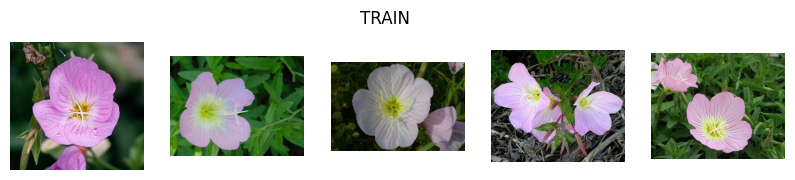

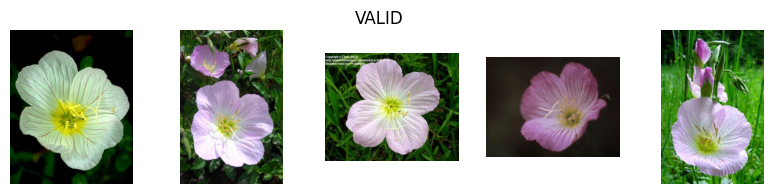

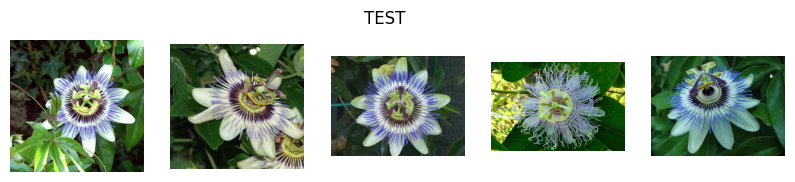

In [5]:
display_images(train_path, "TRAIN")
display_images(valid_path, "VALID")
display_images(test_path, "TEST")

In [6]:
# Collect all images in a given folder into a list
# Stores each image as a dictionary with the relevant metadata
def collect_images(split, folder):
    rows = []

    for i in sorted(os.listdir(folder)):
        folder_path = os.path.join(folder, i)

        if os.path.isdir(folder_path):
            label = i
            for j in sorted(os.listdir(folder_path)):
                rows.append({
                    "split": split,
                    "label": label,
                    "path": os.path.join(folder_path, j),
                    "filename": j
                })
        else:
            rows.append({
                "split": split,
                "label": None,
                "path": folder_path,
                "filename": i
            })

    return rows


In [7]:
# extract all images from each folder, then combine into one dataframe
all_rows = []
all_rows.extend(collect_images("train", train_path))
all_rows.extend(collect_images("valid", valid_path))
all_rows.extend(collect_images("test", test_path))

df = pd.DataFrame(all_rows)
print("Total images found:", len(df))
df.head()


Total images found: 8189


,split,label,path,filename
0,train,1,archive/dataset\train\1\image_06734.jpg,image_06734.jpg
1,train,1,archive/dataset\train\1\image_06735.jpg,image_06735.jpg
2,train,1,archive/dataset\train\1\image_06736.jpg,image_06736.jpg
3,train,1,archive/dataset\train\1\image_06737.jpg,image_06737.jpg
4,train,1,archive/dataset\train\1\image_06738.jpg,image_06738.jpg


In [8]:
print("Total images:", len(df))
print("\nBy split:")
print(df["split"].value_counts())

if df["label"].notnull().any():
    print("\nUnique classes:", df["label"].nunique())
    print("\nTop classes:")
    print(df[df["label"].notnull()]["label"].value_counts().head(10))


Total images: 8189

By split:
split
train    6552
test      819
valid     818
Name: count, dtype: int64

Unique classes: 102

Top classes:
label
51    234
77    226
46    175
89    169
73    166
74    157
81    153
94    146
88    141
78    123
Name: count, dtype: int64


# Sampling Images
Sample 500 images from dataframe and see statistics about image sizes and RGB values

In [9]:
n = min(500, len(df))
paths = df["path"].sample(n, random_state=42).tolist()

width_list, height_list = [], []
means, stds = [], []

for p in paths:
    try:
        with Image.open(p) as im:
            img = im.convert("RGB")
            w, h = img.size

            width_list.append(w)
            height_list.append(h)

            arr = np.array(img) / 255.0
            means.append(arr.mean(axis=(0, 1)))
            stds.append(arr.std(axis=(0, 1)))
    except:
        continue


In [10]:
print("Sampled images:", len(width_list))
print("Width (min, med, max):",
      min(width_list), int(np.median(width_list)), max(width_list))
print("Height (min, med, max):",
      min(height_list), int(np.median(height_list)), max(height_list))

means = np.array(means)
stds  = np.array(stds)

print("Channel means (R,G,B):", np.round(means.mean(axis=0), 4))
print("Channel stds  (R,G,B):", np.round(stds.mean(axis=0), 4))


Sampled images: 500
Width (min, med, max): 500 666 819
Height (min, med, max): 500 500 1022
Channel means (R,G,B): [0.4368 0.3835 0.2923]
Channel stds  (R,G,B): [0.2622 0.2142 0.219 ]


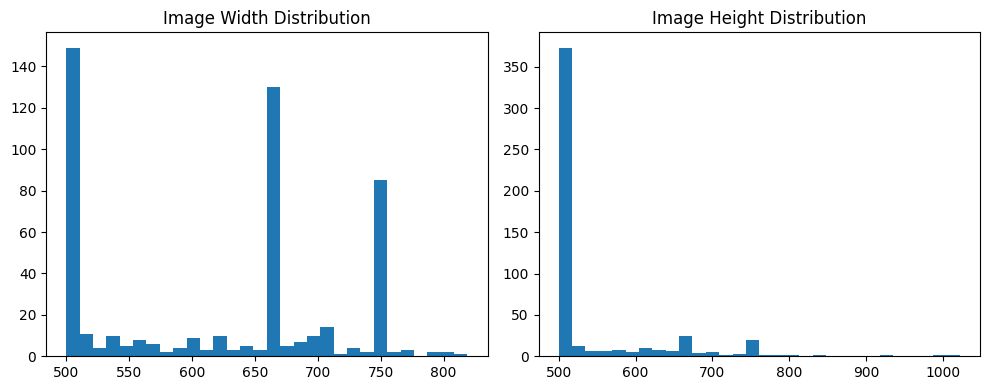

In [11]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(width_list, bins=30)
plt.title("Image Width Distribution")

plt.subplot(1, 2, 2)
plt.hist(height_list, bins=30)
plt.title("Image Height Distribution")

plt.tight_layout()
plt.show()


In [12]:
import json

cat_to_name_path = "archive/cat_to_name.json"

with open(cat_to_name_path, "r") as f:
    cat_to_name = json.load(f)

cat_to_name = {int(k): v for k, v in cat_to_name.items()}


In [13]:
def map_flower_name(label):
    if pd.isna(label):
        return None
    return cat_to_name.get(int(label), None)

df["flower_name"] = df["label"].apply(map_flower_name)


In [14]:
df[df["split"] == "train"][["label", "flower_name"]].tail(20)


,label,flower_name
6532,99,bromelia
6533,99,bromelia
6534,99,bromelia
6535,99,bromelia
6536,99,bromelia
6537,99,bromelia
6538,99,bromelia
6539,99,bromelia
6540,99,bromelia
6541,99,bromelia


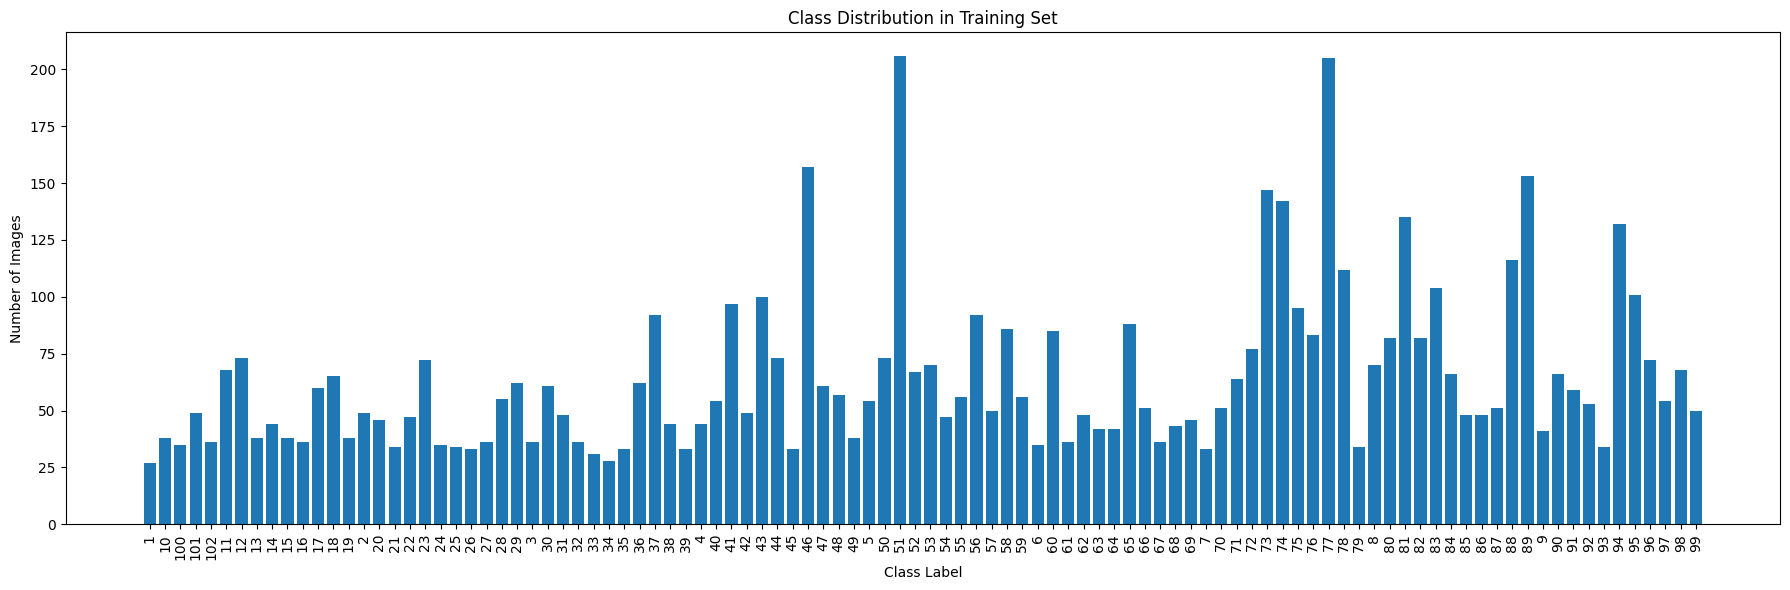

In [15]:
train_df = df[(df["split"] == "train") & (df["label"].notnull())]

class_counts = train_df["label"].value_counts().sort_index()

plt.figure(figsize=(18, 6))
plt.bar(class_counts.index.astype(str), class_counts.values)
plt.xlabel("Class Label")
plt.ylabel("Number of Images")
plt.title("Class Distribution in Training Set")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


In [17]:
#Flattening images into numerical values for use of ANN and LogReg
def flatten_image(df_morph, image_size):

    X, y = [], []

    for row in df_morph.itertuples(index=False):
        img = Image.open(row.path).convert("RGB").resize(image_size)
        X.append(np.array(img))
        y.append(int(row.label))

    return np.array(X), np.array(y)


In [18]:
train_df = df[df["split"] == "train"]
valid_df = df[df["split"] == "valid"]


X_train, y_train = flatten_image(train_df, IMAGE_SIZE)
X_valid, y_valid = flatten_image(valid_df, IMAGE_SIZE)

print("Train shape:", X_train.shape)
print("Valid shape:", X_valid.shape)


Train shape: (6552, 64, 64, 3)
Valid shape: (818, 64, 64, 3)


Per-class counts (train) sample: [(1, 27), (10, 38), (100, 35), (101, 49), (102, 36), (11, 68)]  ...
Target samples per class (largest class): 206


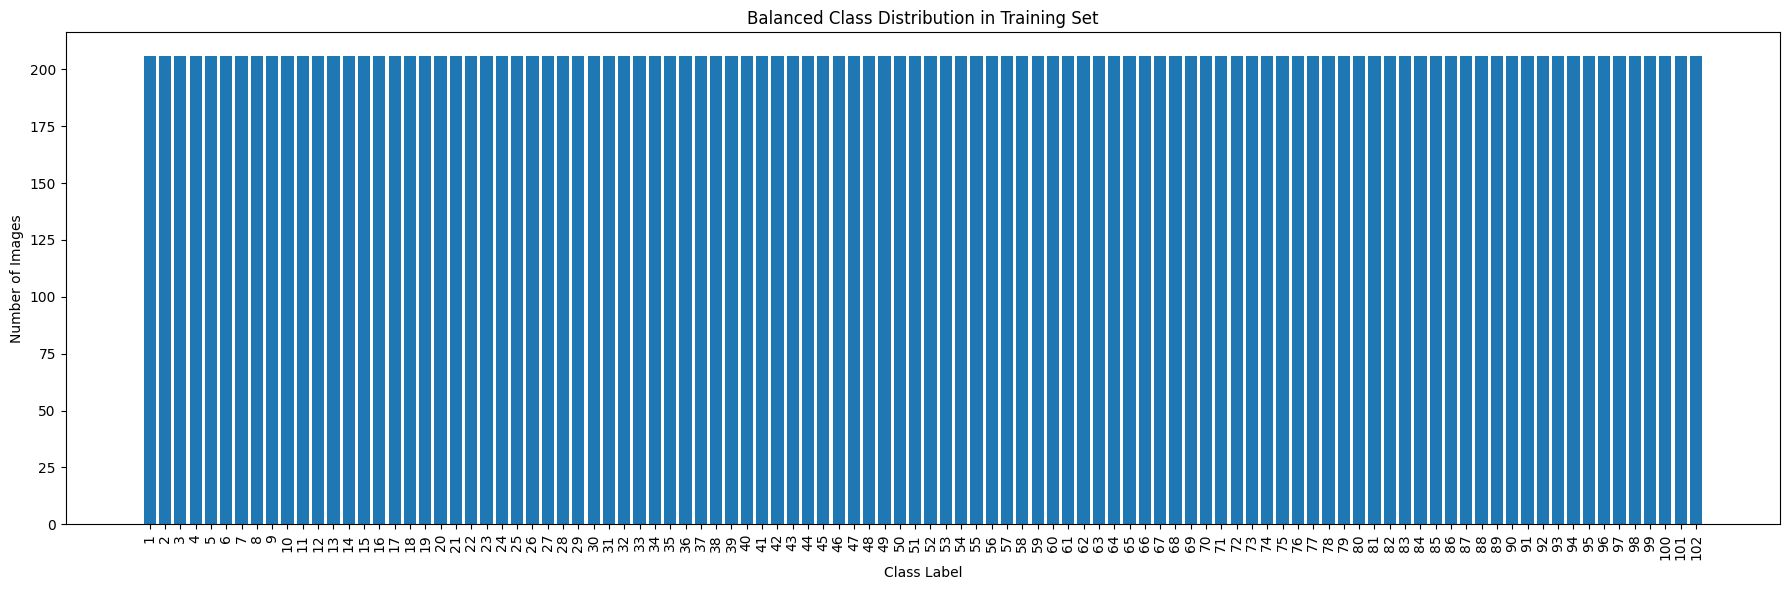

In [21]:
random.seed(42)

# --- augmentation transform (kept mild like we discussed) ---
augment_transform = transforms.Compose([
    transforms.RandomRotation(20),
    transforms.RandomHorizontalFlip(),
    transforms.RandomResizedCrop(size=IMAGE_SIZE, scale=(0.8, 1.0)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
])


train_images_by_class = {}
for i, lbl in enumerate(y_train):
    arr = X_train[i].astype('uint8')            # ensure valid uint8 image
    pil = Image.fromarray(arr)                  # convert to PIL for transforms
    pil = pil.resize(IMAGE_SIZE)                # ensure consistent size
    train_images_by_class.setdefault(int(lbl), []).append(pil)


class_counts = {k: len(v) for k, v in train_images_by_class.items()}
target_count = max(class_counts.values())
print("Per-class counts (train) sample:", list(class_counts.items())[:6], " ...")
print("Target samples per class (largest class):", target_count)


balanced_images = []
balanced_labels = []

for label, imgs in train_images_by_class.items():
    # add originals
    for im in imgs:
        balanced_images.append(np.array(im))   # store as numpy arrays (H,W,C)
        balanced_labels.append(label)

    # augment until we reach target_count
    needed = target_count - len(imgs)
    for _ in range(needed):
        src = random.choice(imgs)
        aug = augment_transform(src)           # PIL -> PIL
        balanced_images.append(np.array(aug))
        balanced_labels.append(label)



balanced_counts = Counter(balanced_labels)

plt.figure(figsize=(18, 6))
plt.bar([str(k) for k in sorted(balanced_counts.keys())],
        [balanced_counts[k] for k in sorted(balanced_counts.keys())])
plt.xlabel("Class Label")
plt.ylabel("Number of Images")
plt.title("Balanced Class Distribution in Training Set")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


In [22]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_valid_flat = X_valid.reshape(X_valid.shape[0], -1)

print("Flattened Train shape:", X_train_flat.shape)
print("Flattened Valid shape:", X_valid_flat.shape)


Flattened Train shape: (6552, 12288)
Flattened Valid shape: (818, 12288)


In [23]:
X_train_norm = X_train_flat / 255.0
X_valid_norm = X_valid_flat / 255.0

print("Train min/max:", X_train_norm.min(), X_train_norm.max())
print("Valid min/max:", X_valid_norm.min(), X_valid_norm.max())


Train min/max: 0.0 1.0
Valid min/max: 0.0 1.0


In [24]:
baseline_lr = LogisticRegression(
    max_iter=2000,
    solver="lbfgs"
)

baseline_lr.fit(X_train_norm, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


In [25]:
y_pred = baseline_lr.predict(X_valid_norm)

print("Baseline Validation Accuracy:",
      accuracy_score(y_valid, y_pred))

print("\nClassification Report:")
print(classification_report(y_valid, y_pred))


Baseline Validation Accuracy: 0.26894865525672373

Classification Report:
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         8
           2       0.67      1.00      0.80         6
           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00         6
           5       0.57      0.57      0.57         7
           6       0.00      0.00      0.00         1
           7       0.00      0.00      0.00         1
           8       0.33      0.40      0.36         5
           9       0.00      0.00      0.00         3
          10       1.00      0.25      0.40         4
          11       0.10      0.10      0.10        10
          12       0.00      0.00      0.00         5
          13       0.00      0.00      0.00         5
          14       0.00      0.00      0.00         1
          15       0.40      0.29      0.33         7
          16       0.00      0.00      0.00         2
       

C:\Users\User\miniconda3\envs\ml\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\miniconda3\envs\ml\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\miniconda3\envs\ml\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [26]:
import numpy as np
from keras.utils import to_categorical

X_train_aug = np.array(balanced_images)
y_train_aug = np.array(balanced_labels)
X_train_aug = X_train_aug.astype("float32") / 255.0
# Training labels are 1..102
y_train_aug = np.array(y_train_aug)  # make sure it's a numpy array

# Shift to 0-based
y_train_zero = y_train_aug - 1

# Number of classes
num_classes = np.max(y_train_zero) + 1  # should be 102

# One-hot encode
y_train_cat = to_categorical(y_train_zero, num_classes=num_classes)

In [27]:
import os
from PIL import Image

img_size = (64, 64)  # same as your model input

# Sorted folder list (numeric sort)
folders = sorted(os.listdir(valid_path), key=lambda x: int(x))  # "1", "2", ..., "102"

# Map folder name → 0-based label
label_map = {folder_name: i for i, folder_name in enumerate(folders)}
print(label_map)  # e.g., {'1':0, '2':1, ..., '102':101}

# Load validation images and labels
X_val = []
y_val = []

for folder in folders:
    folder_path = os.path.join(valid_path, folder)
    for img_file in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_file)
        img = Image.open(img_path).resize(img_size)
        X_val.append(np.array(img))
        y_val.append(label_map[folder])  # 0-based label

X_val = np.array(X_val, dtype="float32") / 255.0
y_val_cat = to_categorical(y_val, num_classes=num_classes)

{'1': 0, '2': 1, '3': 2, '4': 3, '5': 4, '6': 5, '7': 6, '8': 7, '9': 8, '10': 9, '11': 10, '12': 11, '13': 12, '14': 13, '15': 14, '16': 15, '17': 16, '18': 17, '19': 18, '20': 19, '21': 20, '22': 21, '23': 22, '24': 23, '25': 24, '26': 25, '27': 26, '28': 27, '29': 28, '30': 29, '31': 30, '32': 31, '33': 32, '34': 33, '35': 34, '36': 35, '37': 36, '38': 37, '39': 38, '40': 39, '41': 40, '42': 41, '43': 42, '44': 43, '45': 44, '46': 45, '47': 46, '48': 47, '49': 48, '50': 49, '51': 50, '52': 51, '53': 52, '54': 53, '55': 54, '56': 55, '57': 56, '58': 57, '59': 58, '60': 59, '61': 60, '62': 61, '63': 62, '64': 63, '65': 64, '66': 65, '67': 66, '68': 67, '69': 68, '70': 69, '71': 70, '72': 71, '73': 72, '74': 73, '75': 74, '76': 75, '77': 76, '78': 77, '79': 78, '80': 79, '81': 80, '82': 81, '83': 82, '84': 83, '85': 84, '86': 85, '87': 86, '88': 87, '89': 88, '90': 89, '91': 90, '92': 91, '93': 92, '94': 93, '95': 94, '96': 95, '97': 96, '98': 97, '99': 98, '100': 99, '101': 100, '102'

In [28]:
img_size = (64,64)
batch_size = 32


In [29]:
print("Min label:", y_train_aug.min())
print("Max label:", y_train_aug.max())
print("Number of unique labels:", len(np.unique(y_train_aug)))

Min label: 1
Max label: 102
Number of unique labels: 102


In [ ]:
train_datagen_bal = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

train_generator_bal = train_datagen_bal.flow(
    X_train_aug,
    y_train_cat,
    batch_size=batch_size,
    shuffle=True
)


In [ ]:
val_datagen = ImageDataGenerator(rescale=1./255)

val_generator = val_datagen.flow_from_directory(
    valid_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
)
print(val_generator.class_indices)


In [ ]:
model = Sequential([
    tf.keras.Input(shape=(64,64,3)),
    Conv2D(32,(3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128,(3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
history = model.fit(
    train_generator_bal,
    validation_data=(X_val, y_val_cat),
    epochs=50,
    steps_per_epoch=len(train_generator_bal)
)
